# Install libraries

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from scipy.optimize import curve_fit
import seaborn as sns

from pathlib import Path

# Opening cleaned PAROS dataset

In [14]:
CURRENT_DIRECTORY = Path.cwd().resolve()

# Find project root that contains datasets
PROJECT_ROOT = next(
    p for p in [CURRENT_DIRECTORY, *CURRENT_DIRECTORY.parents]
    if (p / "datasets").exists()
)

CLEANED_DATASET_PATH = PROJECT_ROOT / "datasets" / "PAROS_Dataset_Cleaned.csv"

if not CLEANED_DATASET_PATH.exists():
    raise FileNotFoundError(f"Cleaned dataset not found: {CLEANED_DATASET_PATH}")

df = pd.read_csv(CLEANED_DATASET_PATH)
print(f"Loaded cleaned PAROS dataset: {df.shape}")
display(df.head(3))

Loaded cleaned PAROS dataset: (28665, 67)


/tmp/ipykernel_28415/1582093032.py:14: DtypeWarning: Columns (5,32,33,37,43,46,47,48,49,50,51,52,53,60) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(CLEANED_DATASET_PATH)


,Patient brought in by,Date of Incident,Location of incident,Location Unknown,Location Type,Location Type Other,Age,Age Modifier,Gender,Race,...,ANY ROSC,Cause of arrest.1,"If 'Non-Trauma', please specify.1",Reason for discontinuing CPR at ED,Outcome of patient,Patient status,Date of Discharge or Death,Patient neurological status - Cerebral,Patient neurological status - Overall,Patient neurological status - Unknown
0,Ems,2010-04-01,470146.0,NaN,Home Residence,Hdb Level 7,60,Years,Male,Chinese,...,Yes,Non-Trauma,Respiratory,Death,Died In Ed,NaN,NaN,NaN,NaN,NaN
1,Ems,2010-04-01,520926.0,NaN,Home Residence,Hdb Level 2,60,Years,Female,Chinese,...,No,Non-Trauma,Presumed Cardiac Etiology,Death,Died In Ed,NaN,NaN,NaN,NaN,NaN
2,Ems,2010-04-01,560565.0,NaN,Healthcare Facility,Nkf Dialysis Centre,64,Years,Male,Chinese,...,Yes,Non-Trauma,Presumed Cardiac Etiology,Death,Died In Ed,NaN,NaN,NaN,NaN,NaN


In [15]:
print(df.columns.tolist())


['Patient brought in by', 'Date of Incident', 'Location of incident', 'Location Unknown', 'Location Type', 'Location Type Other', 'Age', 'Age Modifier', 'Gender', 'Race', 'Time call received at dispatch center', 'No First Responder dispatched', 'Time First Responder dispatched', 'Time Ambulance dispatched', 'Time First Responder arrived at scene', 'Time Ambulance arrived at scene', 'Time EMS arrived at patient side', 'Time Ambulance arrived at ED', 'Arrest witnessed by', 'Bystander CPR', 'DA-CPR', 'First CPR initiated by', 'Bystander AED applied', 'Resuscitation attempted by EMS/Private ambulance', 'First arrest rhythm', 'Prehospital Defibrillation', 'Time of first shock given', 'Time of first shock Unknown', 'Defibrillation performed by - First Responder', 'Defibrillation performed by - Ambulance Crew', 'Defibrillation performed by - Bystander - Healthcare provider', 'Defibrillation performed by - Bystander - Lay Person', 'Defibrillation performed by - Bystander - Family', 'Other', 'R

# Setting columns for feature engineering

In [16]:
# This will be used to calculate time to defib
call_time_col = 'Time call received at dispatch center'
shock_time_col = 'Time of first shock given'

# This will be used to calculate into a binary status of 0/1 survival
status_col = 'Patient status'

df_survival = df.copy()
# display(df_survival[[call_time_col, shock_time_col, status_col]].head())

# Calculating the time to defib

In [17]:
df_survival["Call_Time"] = pd.to_datetime(df_survival[call_time_col].astype(str),
                                          format = "mixed",
                                          errors='coerce')
df_survival['Shock_Time'] = pd.to_datetime(df_survival[shock_time_col].astype(str),
                                           format='mixed',
                                           errors='coerce')

# Calculate the difference in minutes
df_survival['Time_to_Defib'] = (df_survival['Shock_Time'] - df_survival['Call_Time']).dt.total_seconds() / 60

# Fix midnight crossover overlaps
df_survival.loc[df_survival['Time_to_Defib'] < 0, 'Time_to_Defib'] += 1440

# display(df_survival[['Call_Time', 'Shock_Time', 'Time_to_Defib']].head(10))

/tmp/ipykernel_28415/1114125350.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_survival["Call_Time"] = pd.to_datetime(df_survival[call_time_col].astype(str),
/tmp/ipykernel_28415/1114125350.py:4: FutureWarning: ChainedAssignmentError

Time to defib will show 13.9 minutes (standard decimal format)

Example (Index 0):
-   54 seconds ÷ 60 seconds = 0.90 minutes.
-   13 minutes + 0.90 minutes = 13.90 minutes.

# Feature Engineering for Survival Status

- 0 = Dead
- 1 = Survived

In [18]:
df_survival['Survival_Status'] = df_survival[status_col].astype(str).str.contains('Discharged|Alive|Remains', 
                                                                                  case=False, 
                                                                                  na=False
).astype(int)
df_survival['Survival_Status'] = df_survival['Survival_Status'].astype(int)

# display(df_survival[['Time_to_Defib', 'Survival_Status']].head())

/tmp/ipykernel_28415/942202956.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_survival['Survival_Status'] = df_survival[status_col].astype(str).str.contains('Discharged|Alive|Remains',
/tmp/ipykernel_28415/942202956.py:5: FutureWarni

# Filter to a standard range (e.g., 0-20 minutes)
- This is to avoid extreme outliers skewing the fit

In [19]:
df_plot = df_survival[(df_survival['Time_to_Defib'] >= 0) & (df_survival['Time_to_Defib'] <= 20)].copy()


# Creating 1-minute bins and calculate empirical survival probability
- np.floor rounds times down to the nearest minute 
- 3.4 mins -> 3 mins

In [20]:
df_plot['Time_Bin'] = np.floor(df_plot['Time_to_Defib'])

# Calculate empirical survival probability for each time bin
binned_data = df_plot.groupby('Time_Bin').agg(
    Survival_Probability=('Survival_Status', 'mean'),
    Count=('Survival_Status', 'count')
).reset_index()

/tmp/ipykernel_28415/812873112.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_plot['Time_Bin'] = np.floor(df_plot['Time_to_Defib'])


# Create standard exponential regresion function and fit the curve to the binned data
- Try to do initial parameter guessing

In [21]:
def exp_decay(x, a, b):
    return a * np.exp(-b * x)

x_data = binned_data['Time_Bin']
y_data = binned_data['Survival_Probability']

# Fit the exponential decay model to the data
try:
    popt, _ = curve_fit(exp_decay,
                        x_data,
                        y_data,
                        p0=[0.5, 0.1])
    a_fit, b_fit = popt
except Exception as e:
    print(f"Curve fitting failed: {e}")
    a_fit, b_fit = 0.5, 0.1 # Fallbacks if standard fitting fails

# Generate a continuous smooth line for the fitted curve
x_fit_line = np.linspace(0, 20, 200)
y_fit_line = exp_decay(x_fit_line, a_fit, b_fit)

# Checking for data homogenity

In [22]:
# 1. Convert 'Date of Incident' to a proper datetime format 
df_survival['Date of Incident'] = pd.to_datetime(df_survival['Date of Incident'],
                                                 errors='coerce')

# 2. Extract just the Year into a new column, drop completely missing years to keep chart clean
df_survival['Year'] = df_survival['Date of Incident'].dt.year
df_homogeneity = df_survival.dropna(subset=['Year']).copy()
df_homogeneity['Year'] = df_homogeneity['Year'].astype(int)

# 3. Ensure 'Bystander CPR' is binary (1 for Yes, 0 for No)
df_homogeneity['Bystander_CPR_Binary'] = df_homogeneity['Bystander CPR'].astype(str).str.contains('Yes',
                                                                                                  case=False,
                                                                                                  na=False).astype(int)

# 4. Group by Year
yearly_stats = df_homogeneity.groupby('Year').agg(
    Total_Cases=('Case #', 'count'),          # Counts the number of rows per year
    CPR_Rate=('Bystander_CPR_Binary', 'mean') # Calculates the % of cases with CPR
).reset_index()

# Convert CPR rate to a clean percentage
yearly_stats['CPR_Rate'] = yearly_stats['CPR_Rate'] * 100

/tmp/ipykernel_28415/3554030872.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_survival['Date of Incident'] = pd.to_datetime(df_survival['Date of Incident'],
/tmp/ipykernel_28415/3554030872.py:6: FutureWarning: ChainedAssignmentError

KeyError: "Column(s) ['Case #'] do not exist"

# Plotting Dual-Axis Chart

/home/axlee/miniconda3/envs/geospatial_env/lib/python3.14/site-packages/seaborn/_base.py:1447: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  self.plot_data[axis] = cat_data
/home/axlee/miniconda3/envs/geospatial_env/lib/python3.14/site-packa

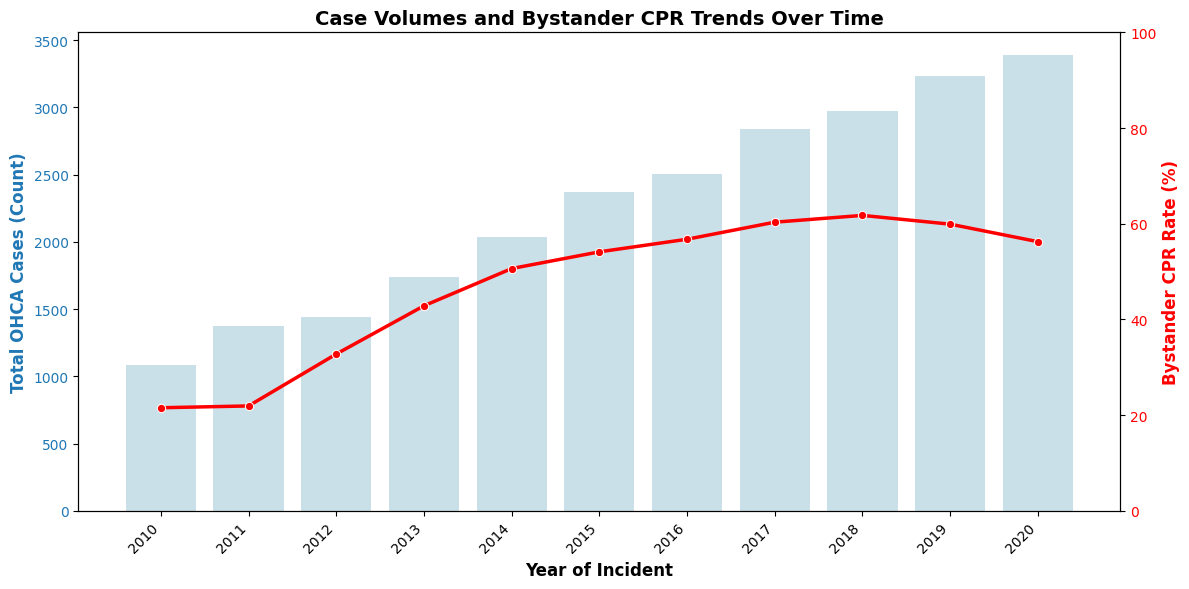

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# --- Axis 1: Case Volumes (Bar Chart) ---
sns.barplot(data=yearly_stats,
            x='Year',
            y='Total_Cases',
            color='lightblue',
            ax=ax1,
            alpha=0.7)
ax1.set_ylabel('Total OHCA Cases (Count)',
               color='tab:blue',
               fontsize=12,
               fontweight='bold')
ax1.tick_params(axis='y',
                labelcolor='tab:blue')
ax1.set_xlabel('Year of Incident',
               fontsize=12,
               fontweight='bold')

# Rotate x-axis labels in case years get crowded
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

# --- Axis 2: Bystander CPR Rate (Line Chart) ---
# Create a second y-axis that shares the same x-axis
ax2 = ax1.twinx() 
# Seaborn lineplot handles the secondary axis differently with categorical x-axis, 
# so we map to the index positions of the bars
sns.lineplot(x=range(len(yearly_stats)),
             y=yearly_stats['CPR_Rate'],
             color='red',
             marker='o',
             linewidth=2.5,
             ax=ax2)
ax2.set_ylabel('Bystander CPR Rate (%)',
               color='red',
               fontsize=12,
               fontweight='bold')
ax2.tick_params(axis='y',
                labelcolor='red')
ax2.set_ylim(0, 100) # Lock the percentage axis from 0 to 100

# Formatting
plt.title('Case Volumes and Bystander CPR Trends Over Time',
          fontsize=14,
          fontweight='bold')
ax1.grid(False)
ax2.grid(False) 
plt.tight_layout()

plt.show()

# Plot the 3-Way Baseline

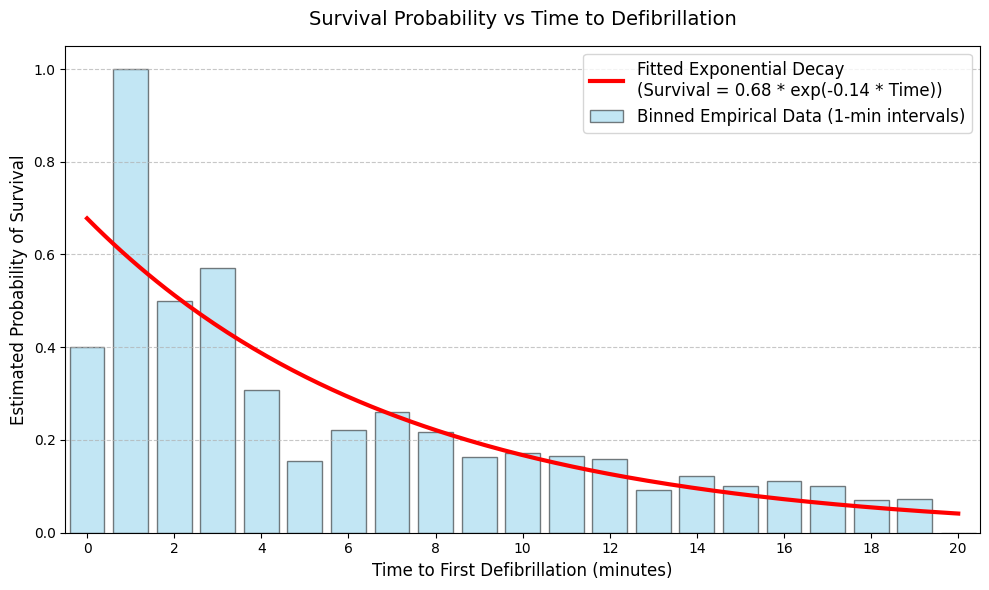

In [ ]:
plt.figure(figsize=(10, 6))

# Histogram / Bar representation of the binned actual probabilities
plt.bar(x_data,
        y_data,
        width=0.8,
        alpha=0.5,
        color='skyblue',
        edgecolor='black', 
        label='Binned Empirical Data (1-min intervals)')

# Plot the exact scatter dots as well
# plt.scatter(x_data, y_data, color='blue', zorder=3)

# The smooth exponential curve
plt.plot(x_fit_line,
         y_fit_line,
         color='red',
         linewidth=3,
         label=f'Fitted Exponential Decay\n(Survival = {a_fit:.2f} * exp(-{b_fit:.2f} * Time))')

# Aesthetics
plt.title('Survival Probability vs Time to Defibrillation',
          fontsize=14,
          pad=15)
plt.xlabel('Time to First Defibrillation (minutes)',
           fontsize=12)
plt.ylabel('Estimated Probability of Survival',
           fontsize=12)
plt.xticks(np.arange(0, 21, 2))
plt.xlim(-0.5, 20.5)
plt.grid(axis='y',
         linestyle='--',
         alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()

plt.show()